# Is the amount of sleep teenagers got when it isn't a school night associated with the amount of sleep teenagers when it is a school night?
This would be a observational study because I on;y have access to a sample of data collected from the ASA. This is not representive of the high school population in the US. 

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import numpy as np

AtSchool = pd.read_csv("CensusAtSchool_Categorized_Sleep.csv")

In [3]:
AtSchool.head()

,Country,Region,DataYear,ClassGrade,Gender,Ageyears,Handed,Height_cm,Footlength_cm,Armspan_cm,...,Work_At_Home_Hours,Schoolwork_Pressure,Planned_Education_Level,Favorite_Music,Superpower,Preferred_Status,Role_Model_Type,Charity_Donation,School_Night_Sleep_Category,Non_School_Night_Sleep_Category
0,USA,CA,2026,12,Male,17,Right-Handed,185,33,186,...,4,Some,High school,Pop,Fly,Rich,Sports person,International aid,Average,A little
1,USA,ID,2026,12,Female,18,Right-Handed,160,23,150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Average,Average
2,USA,GA,2026,12,Male,16,Right-Handed,179,28,92,...,2,Some,Graduate degree,Classical,Super strength,Happy,Musician or singer,Education/Youth development,Average,Average
3,USA,CA,2026,12,Male,17,Right-Handed,170,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,USA,OK,2026,11,Female,17,Right-Handed,167.6,22.9,165.1,...,0,Some,Some college,Rhythm and blues (R&B),Telepathy,Rich,Musician or singer,"Wildlife, animals",Average,Average


In [4]:
AtSchool.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 62 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country                           500 non-null    str    
 1   Region                            500 non-null    str    
 2   DataYear                          500 non-null    int64  
 3   ClassGrade                        500 non-null    int64  
 4   Gender                            496 non-null    str    
 5   Ageyears                          500 non-null    int64  
 6   Handed                            493 non-null    str    
 7   Height_cm                         489 non-null    str    
 8   Footlength_cm                     470 non-null    str    
 9   Armspan_cm                        461 non-null    str    
 10  Languages_spoken                  492 non-null    str    
 11  Travel_to_School                  489 non-null    str    
 12  Travel_time_to_Scho

In [17]:
Sleep=AtSchool["School_Night_Sleep_Category"]
Sleep

0       Average
1       Average
2       Average
3           NaN
4       Average
         ...   
495    A little
496     Average
497     Average
498     Average
499     Average
Name: School_Night_Sleep_Category, Length: 500, dtype: str

In [18]:
count = len(Sleep)
print("Sleep",count)

Sleep 500


In [20]:
Hours=AtSchool["Non_School_Night_Sleep_Category"]
Hours

0      A little
1       Average
2       Average
3           NaN
4       Average
         ...   
495     Average
496     Average
497     Average
498     Average
499     Average
Name: Non_School_Night_Sleep_Category, Length: 500, dtype: str

In [9]:
count = len(Hours)
print("Hours", count)

Hours 500


<Axes: xlabel='School_Night_Sleep_Category', ylabel='count'>

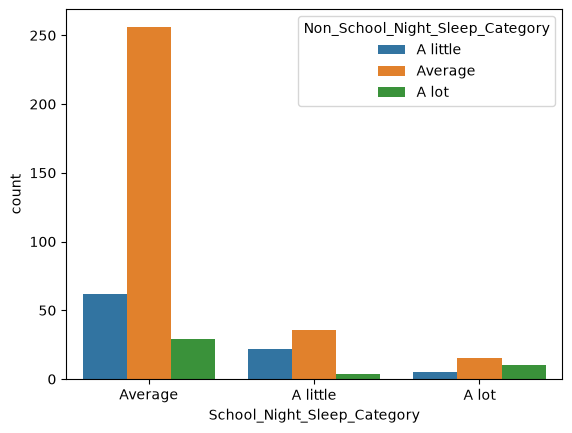

In [21]:
sns.countplot(AtSchool, x=Sleep, hue= Hours)

In [22]:
raw_data = ['6', '7', '8', '4', '9', '4.5', '5', '10', '11:00', '8-9', '10.30', 
            '5-7', '7-8', '6.5', '9.5', '5 hrs', '8.5', '12', '6-7', '7.5', 
            '6-10', '3', '6-5', '8', '5 1/2', '5-6', '7-9', '5hr', '2', '5.5', '6-8', '4-5']
AfterSchool = pd.DataFrame({'School_Night_Sleep_Category': raw_data})
def convert_to_hours(val):
    val = str(val).lower().strip()
    
    # Handle fractions (e.g., '5 1/2')S
    if '1/2' in val:
        val = val.replace('1/2', '.5')
    
    # Remove text/units like 'hrs', 'hr'
    val = re.sub(r'[a-z]', '', val).strip()
    
    # Handle time formats like '11:00'
    if ':' in val:
        parts = val.split(':')
        return float(parts[0]) + float(parts[1]) / 60
    
    # Handle ranges like '7-8' or '4-5' by taking the average
    if '-' in val:
        parts = val.split('-')
        try:
            return (float(parts[0]) + float(parts[1])) / 2
        except ValueError:
            return None
            
    # Convert standard numerical strings
    try:
        return float(val)
    except ValueError:
        return None

# Apply cleaning function
AfterSchool['Non_School_Night_Sleep_Category'] = AfterSchool['School_Night_Sleep_Category'].apply(convert_to_hours)

print(AfterSchool)

   School_Night_Sleep_Category  Non_School_Night_Sleep_Category
0                            6                              6.0
1                            7                              7.0
2                            8                              8.0
3                            4                              4.0
4                            9                              9.0
5                          4.5                              4.5
6                            5                              5.0
7                           10                             10.0
8                        11:00                             11.0
9                          8-9                              8.5
10                       10.30                             10.3
11                         5-7                              6.0
12                         7-8                              7.5
13                         6.5                              6.5
14                         9.5          

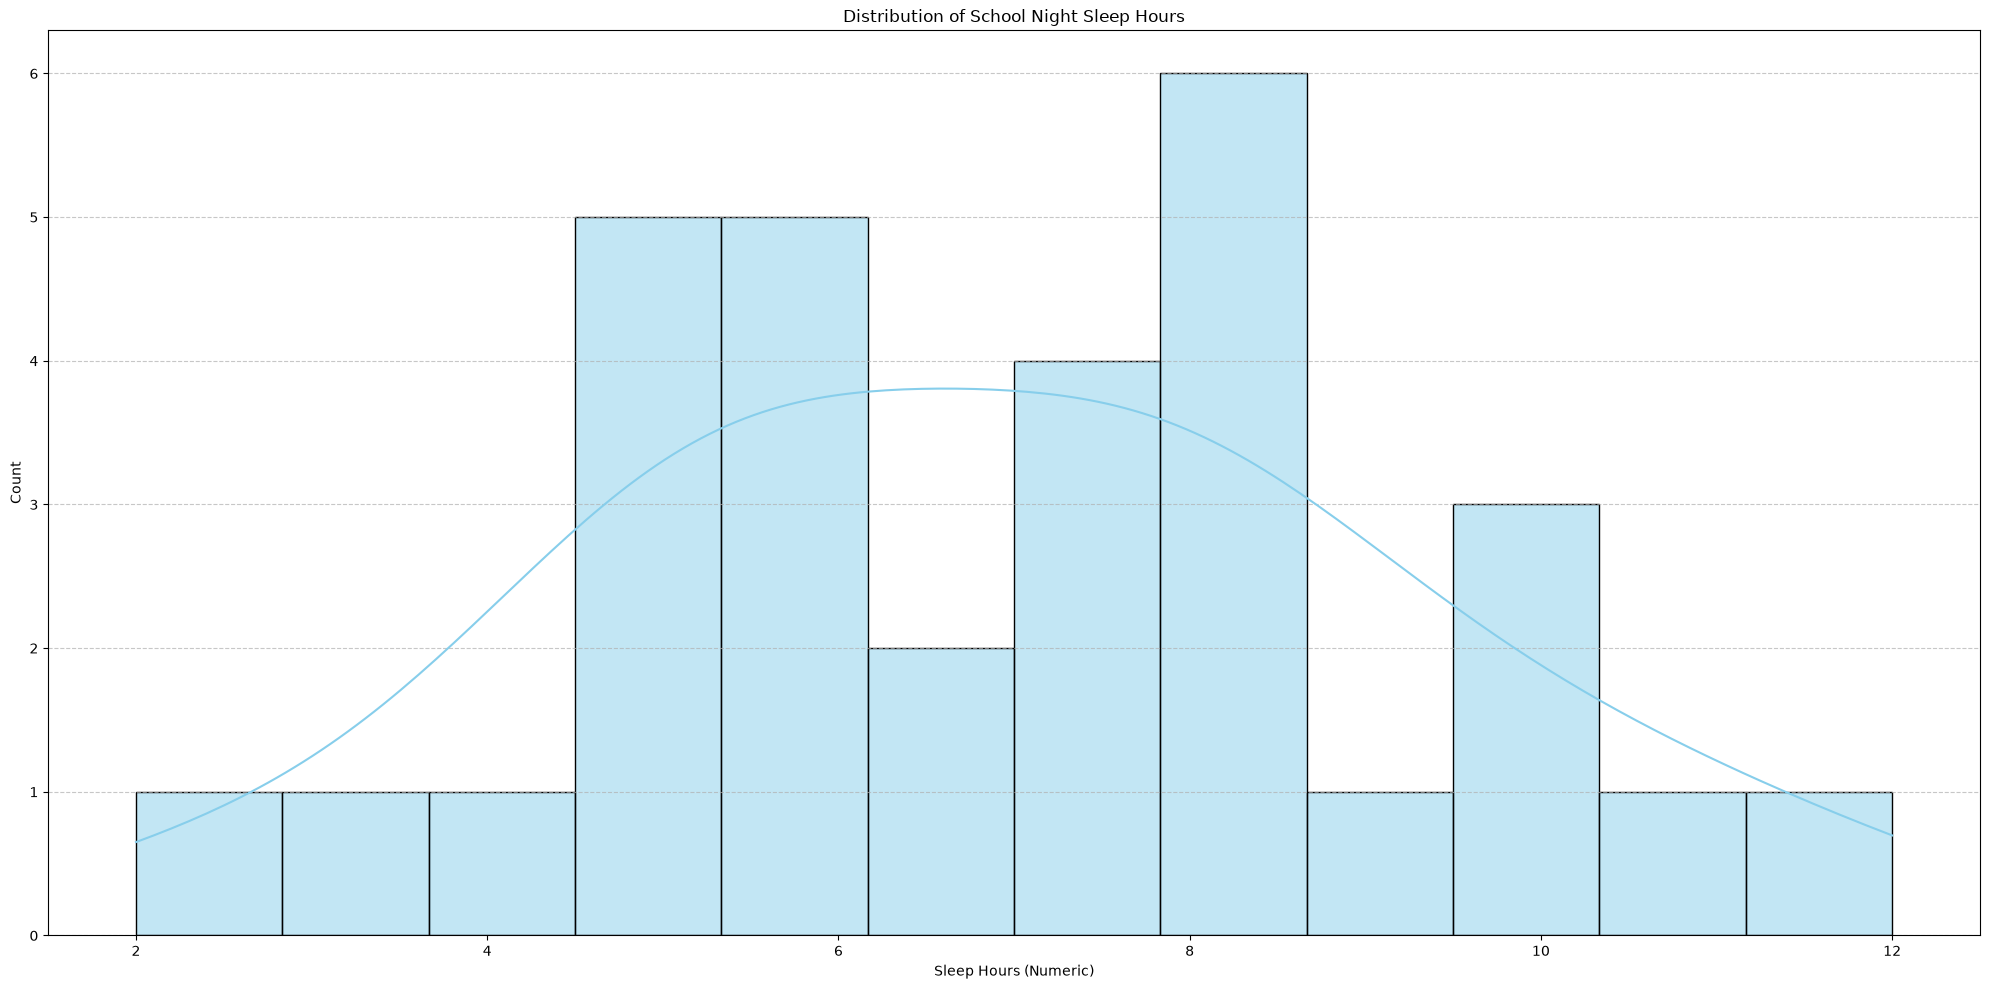

In [24]:
plt.figure(figsize=(20, 10))
sns.histplot(
    AfterSchool['Non_School_Night_Sleep_Category'].dropna(), 
    kde=True, 
    color='skyblue', 
    bins=12, 
    edgecolor='black')

plt.title('Distribution of School Night Sleep Hours')
plt.xlabel('Sleep Hours (Numeric)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [25]:
raw_data = ['6', '7', '8', '4', '9', '4.5', '5', '10', '11:00', '8-9', '10.30', 
            '5-7', '7-8', '6.5', '9.5', '5 hrs', '8.5', '12', '6-7', '7.5', 
            '6-10', '3', '6-5', '8', '5 1/2', '5-6', '7-9', '5hr', '2', '5.5', '6-8', '4-5']
AfterSchool = pd.DataFrame({'Non_School_Night_Sleep_Category': raw_data})
def convert_to_hours(val):
    val = str(val).lower().strip()
    
    # Handle fractions (e.g., '5 1/2')
    if '1/2' in val:
        val = val.replace('1/2', '.5')
    
    # Remove text/units like 'hrs', 'hr'
    val = re.sub(r'[a-z]', '', val).strip()
    
    # Handle time formats like '11:00'
    if ':' in val:
        parts = val.split(':')
        return float(parts[0]) + float(parts[1]) / 60
    
    # Handle ranges like '7-8' or '4-5' by taking the average
    if '-' in val:
        parts = val.split('-')
        try:
            return (float(parts[0]) + float(parts[1])) / 2
        except ValueError:
            return None
            
    # Convert standard numerical strings
    try:
        return float(val)
    except ValueError:
        return None

# Apply cleaning function
AfterSchool['Non_School_Night_Sleep_Category'] = AfterSchool['Non_School_Night_Sleep_Category'].apply(convert_to_hours)

print(AfterSchool)

    Non_School_Night_Sleep_Category
0                               6.0
1                               7.0
2                               8.0
3                               4.0
4                               9.0
5                               4.5
6                               5.0
7                              10.0
8                              11.0
9                               8.5
10                             10.3
11                              6.0
12                              7.5
13                              6.5
14                              9.5
15                              5.0
16                              8.5
17                             12.0
18                              6.5
19                              7.5
20                              8.0
21                              3.0
22                              5.5
23                              8.0
24                              NaN
25                              5.5
26                          

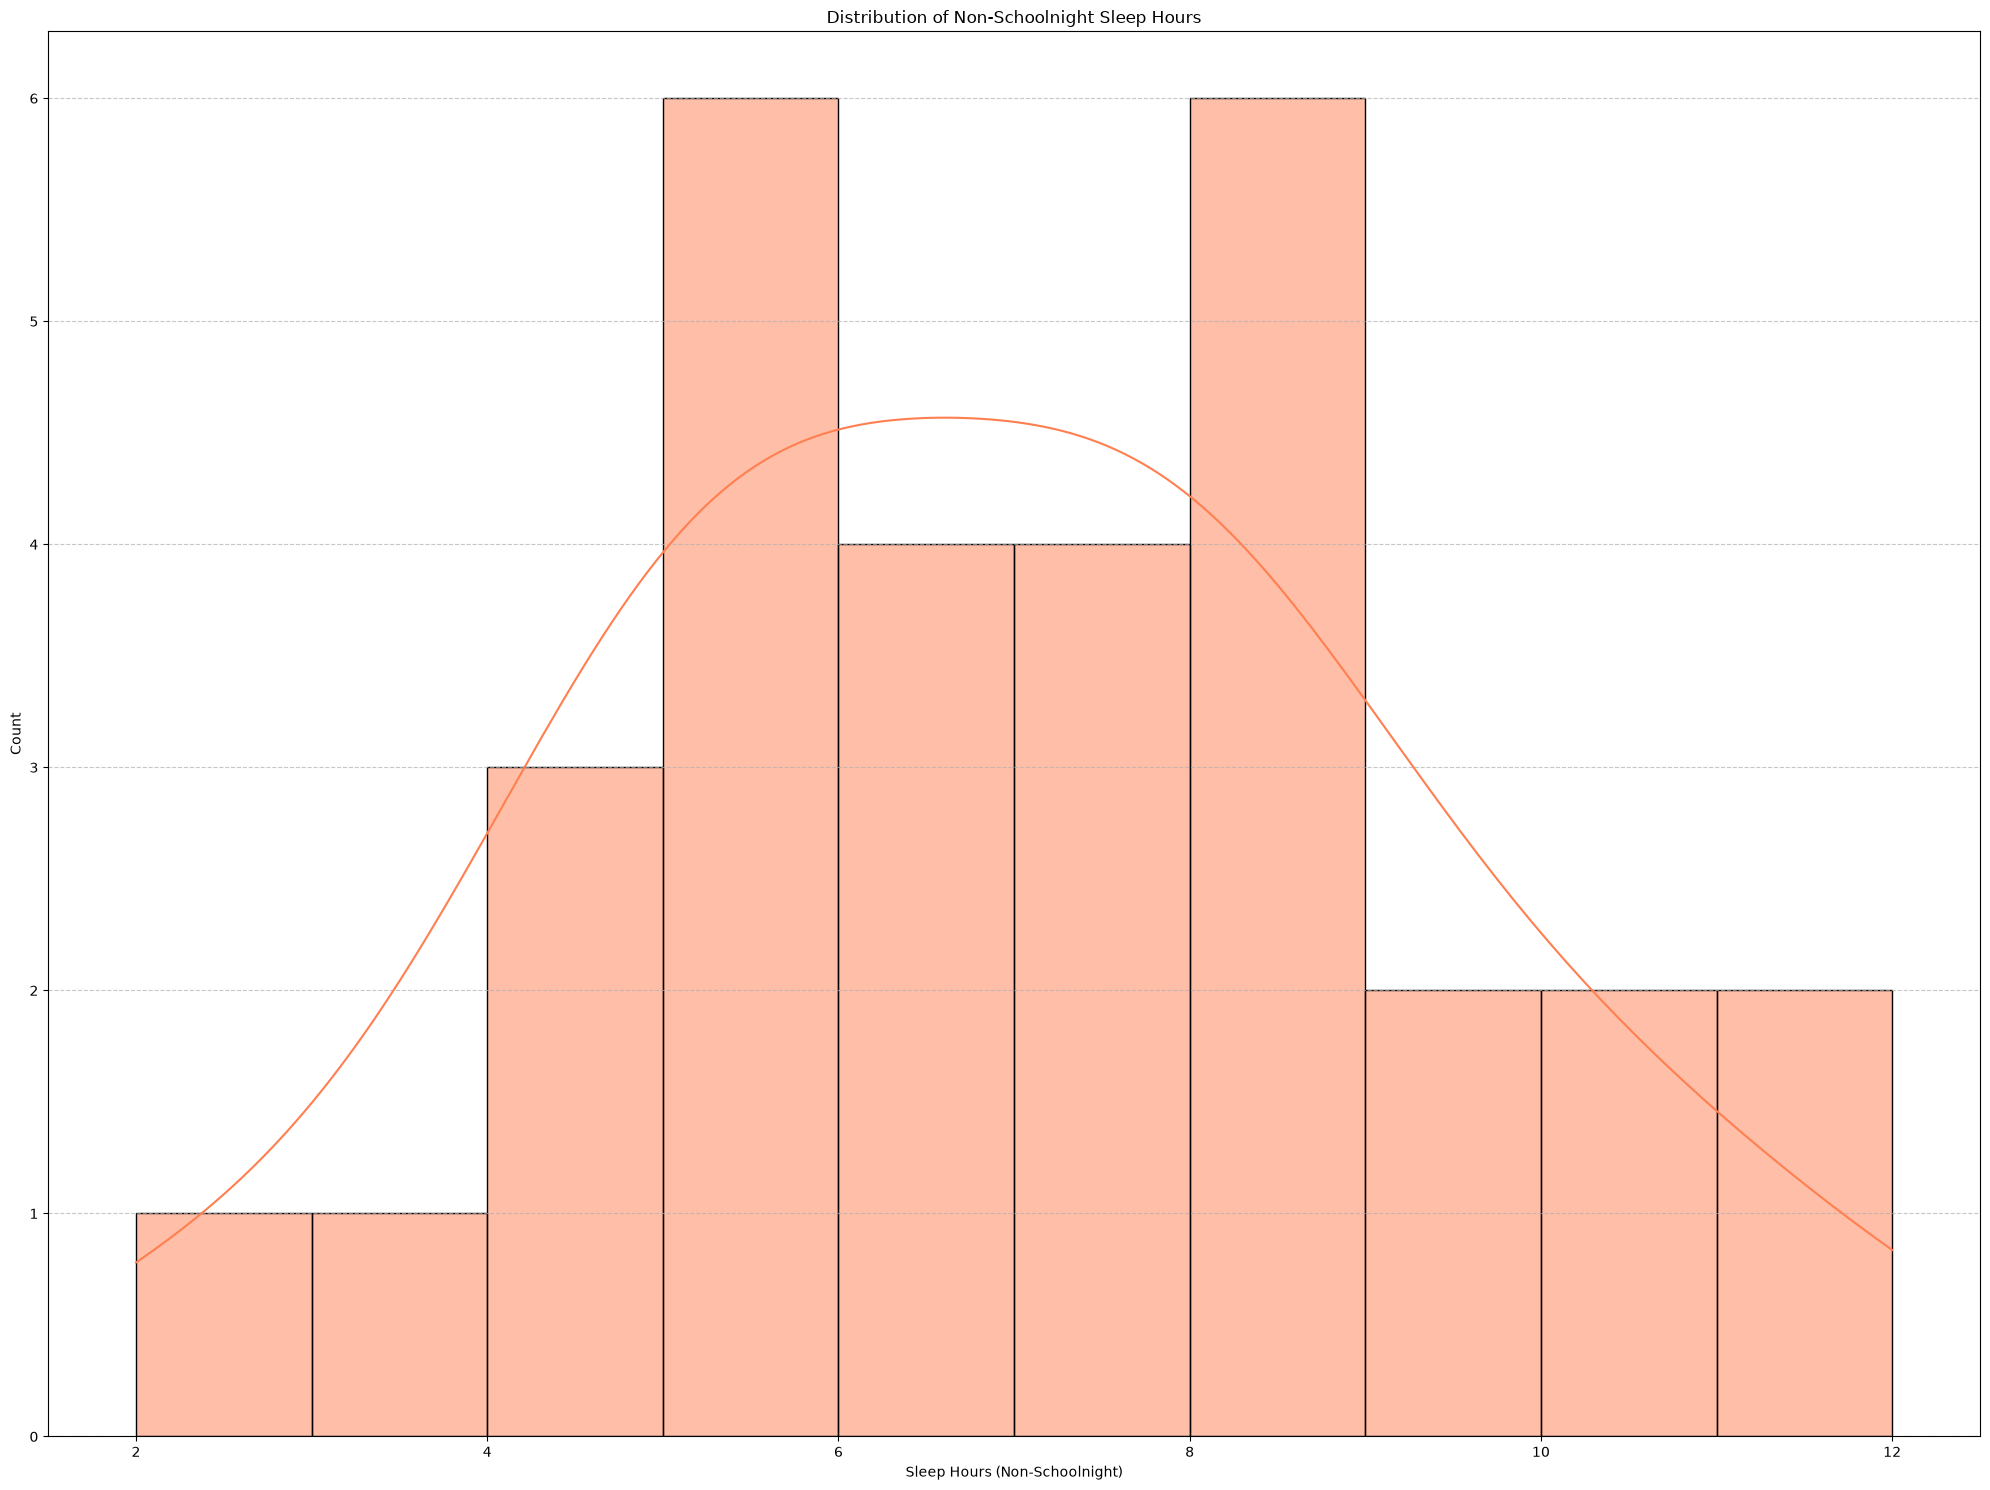

In [26]:
data = [
    6.0,
    7.0,
    8.0,
    4.0,
    9.0,
    4.5,
    5.0,
    10.0,
    11.0,
    8.5,
    10.3,
    6.0,
    7.5,
    6.5,
    9.5,
    5.0,
    8.5,
    12.0,
    6.5,
    7.5,
    8.0,
    3.0,
    5.5,
    8.0,
    np.nan,
    5.5,
    8.0,
    5.0,
    2.0,
    5.5,
    7.0,
    4.5,]
AfterSchool = pd.DataFrame({'Non_School_Night_Sleep_Category': data})
plt.figure(figsize=(20, 15))
sns.histplot(
    AfterSchool['Non_School_Night_Sleep_Category'].dropna(),
    kde=True,
    color='coral',
    bins=10,
    edgecolor='black',
)

plt.title('Distribution of Non-Schoolnight Sleep Hours')
plt.xlabel('Sleep Hours (Non-Schoolnight)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [27]:
pd.crosstab(Sleep, Hours, margins=True)

Non_School_Night_Sleep_Category,A little,A lot,Average,All
School_Night_Sleep_Category,,,,
A little,22,4,36,62
A lot,5,10,15,30
Average,62,29,256,347
All,89,43,307,439


In [28]:
22/62

0.3548387096774194

In [29]:
5/30

0.16666666666666666

In [30]:
62/347

0.1786743515850144

In [31]:
89/439

0.20273348519362186

## Conclusion
based on the data that was given we can see that most students get an average amount of sleep on both a school night and when it isn't a school night. The conditional relative frequency is different for each category because each of the numbers for the cagetories are different and we know based on the two bar graphs for each category we see that between 5.5-8 hours is the most average a teenager would get no matter if it is or isn't a school night. 